In [18]:
import os
import random
import numpy as np
import pandas as pd         
from glob import glob        
import shutil                
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

import matplotlib.pyplot as plt

# Configuration 
class CFG:
    # Dataset
    DATASET_PATH = "/kaggle/input/prdb-rice/Original_Images"
    IMG_EXTS = (".jpg",)
    
    # Image settings
    IMG_SIZE = 224
    
    # Reproducibility
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # SSL training
    SSL_BATCH = 64
    SSL_EPOCHS = 150
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    
    # Output
    OUT_DIR = "/kaggle/working/prdb_ssl"

# Create output directory if not exists
os.makedirs(CFG.OUT_DIR, exist_ok=True)

#Seed Setting 
def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()



In [19]:
# 1. Class Map for PRDB
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna":9
}

PRDB_ROOT = "/kaggle/input/datasets/farhananuren/prdb-rice/Original_Images"

assert os.path.exists(PRDB_ROOT), "ERROR: PRDB dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)


# 2. Build Image Index
def build_index(root=PRDB_ROOT):
    rows = []
    for cls, lbl in CLASS_MAP.items():
        cls_folder = os.path.join(root, cls)
        for img_path in glob(os.path.join(cls_folder, "*")):
            if not img_path.lower().endswith(CFG.IMG_EXTS):
                continue
            rows.append({"image": img_path, "label": lbl, "cls": cls})
    df = pd.DataFrame(rows)
    print("Counts per class:\n", df["cls"].value_counts())
    return df

df_all = build_index(PRDB_ROOT)


[INFO] Using PRDB root: /kaggle/input/datasets/farhananuren/prdb-rice/Original_Images
Counts per class:
 cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64


In [20]:
import shutil
import os
from sklearn.model_selection import train_test_split


base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")
val_dir = os.path.join(base_split_dir, "val")
test_dir = os.path.join(base_split_dir, "test")


os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Splitting dataset into train (70%), val (10% of training), test (30%) for each class: ")

for class_name, class_label in CLASS_MAP.items():
    # Filter images of current class
    class_df = df_all[df_all['cls'] == class_name]
    images_full_paths = class_df['image'].tolist()

    if not images_full_paths:
        print(f"[WARN] No images found for class {class_name}. Skipping.")
        continue

    #  train 70%, test 30%
    train_imgs, test_imgs = train_test_split(
        images_full_paths, test_size=0.30, random_state=CFG.SEED
    )

    # allocate 10% of training as validation
    val_size = 0.10  # 10% of training
    train_imgs, val_imgs = train_test_split(
        train_imgs, test_size=val_size, random_state=CFG.SEED
    )


    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(d, class_name), exist_ok=True)


    for img_path in train_imgs:
        shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
    for img_path in val_imgs:
        shutil.copy(img_path, os.path.join(val_dir, class_name, os.path.basename(img_path)))
    for img_path in test_imgs:
        shutil.copy(img_path, os.path.join(test_dir, class_name, os.path.basename(img_path)))

    print(f"{class_name}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")


Splitting dataset into train (70%), val (10% of training), test (30%) for each class: 
Aush: Train=126, Val=14, Test=60
Beroi: Train=126, Val=14, Test=60
BR-28: Train=126, Val=14, Test=60
BR-29: Train=126, Val=14, Test=60
Chinigura: Train=126, Val=14, Test=60
Ghee Bhog: Train=126, Val=14, Test=60
Katari Najir: Train=126, Val=14, Test=60
Katari Siddho: Train=126, Val=14, Test=60
Miniket: Train=126, Val=14, Test=60
Swarna: Train=126, Val=14, Test=60


In [21]:
!pip install lightly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 24.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Starting Training


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


epoch: 00, loss: 4.21136
epoch: 01, loss: 4.10801
epoch: 02, loss: 4.08449
epoch: 03, loss: 4.02934
epoch: 04, loss: 3.94774
epoch: 05, loss: 3.84314
epoch: 06, loss: 3.88039
epoch: 07, loss: 3.79447
epoch: 08, loss: 3.68724
epoch: 09, loss: 3.63301
epoch: 10, loss: 3.60585
epoch: 11, loss: 3.55677
epoch: 12, loss: 3.51181
epoch: 13, loss: 3.45371
epoch: 14, loss: 3.42630
epoch: 15, loss: 3.41358
epoch: 16, loss: 3.37161
epoch: 17, loss: 3.37045
epoch: 18, loss: 3.30683
epoch: 19, loss: 3.31151
epoch: 20, loss: 3.30497
epoch: 21, loss: 3.24677
epoch: 22, loss: 3.28641
epoch: 23, loss: 3.24530
epoch: 24, loss: 3.23244
epoch: 25, loss: 3.25109
epoch: 26, loss: 3.24523
epoch: 27, loss: 3.19223
epoch: 28, loss: 3.18807
epoch: 29, loss: 3.22362
epoch: 30, loss: 3.18503
epoch: 31, loss: 3.14532
epoch: 32, loss: 3.15763
epoch: 33, loss: 3.16650
epoch: 34, loss: 3.12864
epoch: 35, loss: 3.15788
epoch: 36, loss: 3.12272
epoch: 37, loss: 3.17790
epoch: 38, loss: 3.15854
epoch: 39, loss: 3.13089


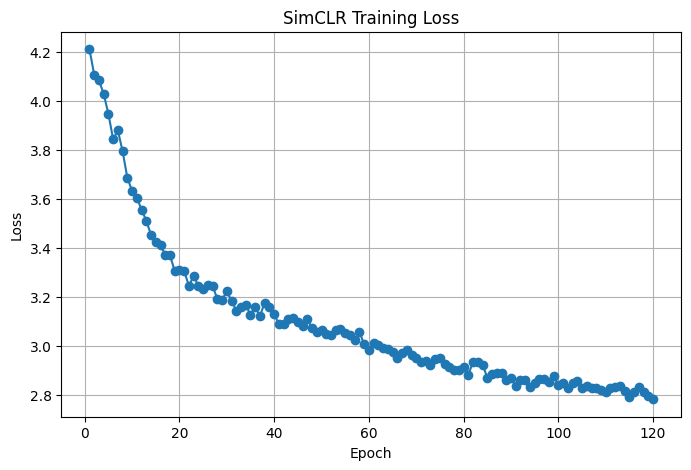

In [22]:
import torch
import torchvision
from torch import nn

from lightly.loss import NTXentLoss
from lightly.models.modules import SimCLRProjectionHead
from lightly.transforms.simclr_transform import SimCLRTransform
from lightly.data import LightlyDataset   # <-- added


class SimCLR(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        # DenseNet-121 output features = 1024
        self.projection_head = SimCLRProjectionHead(1024, 1024, 128)

    def forward(self, x):
        x = self.backbone(x).flatten(start_dim=1)
        z = self.projection_head(x)
        return z


densenet = torchvision.models.densenet121(weights=None)

backbone = nn.Sequential(
    densenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # global avg pool
)

model = SimCLR(backbone)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


transform = SimCLRTransform(input_size=224, gaussian_blur=0.0)

dataset = LightlyDataset(
    input_dir="/kaggle/working/prdb_ssl/split_data/train",
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=8,
)


criterion = NTXentLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.06)
all_losses = []

print("Starting Training")
for epoch in range(120):
    total_loss = 0
    for batch in dataloader:
        (x0, x1), _, _ = batch   # labels exist but ignored
        x0 = x0.to(device)
        x1 = x1.to(device)

        z0 = model(x0)
        z1 = model(x1)

        loss = criterion(z0, z1)
        total_loss += loss.detach()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(dataloader)
    all_losses.append(avg_loss.cpu().item()) 
    print(f"epoch: {epoch:>02}, loss: {avg_loss:.5f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(all_losses)+1), all_losses, marker='o')
plt.title("SimCLR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


****Linear Probe****

Epoch 1/80 Train Acc: 50.95%
Epoch 2/80 Train Acc: 74.05%
Epoch 3/80 Train Acc: 76.51%
Epoch 4/80 Train Acc: 77.78%
Epoch 5/80 Train Acc: 80.00%
Epoch 6/80 Train Acc: 80.40%
Epoch 7/80 Train Acc: 81.83%
Epoch 8/80 Train Acc: 82.30%
Epoch 9/80 Train Acc: 83.89%
Epoch 10/80 Train Acc: 83.10%
Epoch 11/80 Train Acc: 85.16%
Epoch 12/80 Train Acc: 84.84%
Epoch 13/80 Train Acc: 84.37%
Epoch 14/80 Train Acc: 85.00%
Epoch 15/80 Train Acc: 85.40%
Epoch 16/80 Train Acc: 85.79%
Epoch 17/80 Train Acc: 85.16%
Epoch 18/80 Train Acc: 86.03%
Epoch 19/80 Train Acc: 85.95%
Epoch 20/80 Train Acc: 86.27%
Epoch 21/80 Train Acc: 87.14%
Epoch 22/80 Train Acc: 86.83%
Epoch 23/80 Train Acc: 86.59%
Epoch 24/80 Train Acc: 86.75%
Epoch 25/80 Train Acc: 86.43%
Epoch 26/80 Train Acc: 86.83%
Epoch 27/80 Train Acc: 87.38%
Epoch 28/80 Train Acc: 88.02%
Epoch 29/80 Train Acc: 87.54%
Epoch 30/80 Train Acc: 87.62%
Epoch 31/80 Train Acc: 88.33%
Epoch 32/80 Train Acc: 87.94%
Epoch 33/80 Train Acc: 88.73%
Epoch 34/80 Train A

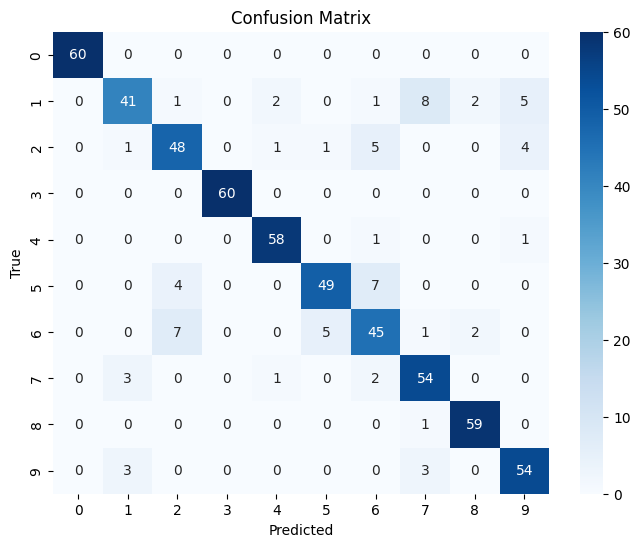

In [23]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# Linear probe
class LinearProbe(nn.Module):
    def __init__(self, backbone, feature_dim=1024, num_classes=10):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x).flatten(1)
        return self.classifier(features)

model = LinearProbe(backbone, feature_dim=1024, num_classes=10).to(device)

# Data loaders
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])

train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.01, momentum=0.9)
epochs = 80

for epoch in range(epochs):
    model.train()
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}/{epochs} Train Acc: {100*correct/total:.2f}%")

# Evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nFINAL TEST ACCURACY: {100*correct/total:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

# Confusion matrix as image
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


****MLP****

Epoch 1/80 Train Acc: 42.70%
Epoch 2/80 Train Acc: 64.44%
Epoch 3/80 Train Acc: 70.87%
Epoch 4/80 Train Acc: 74.13%
Epoch 5/80 Train Acc: 75.87%
Epoch 6/80 Train Acc: 76.59%
Epoch 7/80 Train Acc: 76.83%
Epoch 8/80 Train Acc: 78.17%
Epoch 9/80 Train Acc: 79.84%
Epoch 10/80 Train Acc: 78.65%
Epoch 11/80 Train Acc: 80.08%
Epoch 12/80 Train Acc: 81.75%
Epoch 13/80 Train Acc: 81.59%
Epoch 14/80 Train Acc: 82.22%
Epoch 15/80 Train Acc: 83.97%
Epoch 16/80 Train Acc: 83.73%
Epoch 17/80 Train Acc: 83.33%
Epoch 18/80 Train Acc: 83.97%
Epoch 19/80 Train Acc: 82.86%
Epoch 20/80 Train Acc: 85.87%
Epoch 21/80 Train Acc: 83.89%
Epoch 22/80 Train Acc: 85.32%
Epoch 23/80 Train Acc: 85.87%
Epoch 24/80 Train Acc: 85.63%
Epoch 25/80 Train Acc: 86.03%
Epoch 26/80 Train Acc: 87.54%
Epoch 27/80 Train Acc: 85.63%
Epoch 28/80 Train Acc: 88.65%
Epoch 29/80 Train Acc: 86.27%
Epoch 30/80 Train Acc: 85.24%
Epoch 31/80 Train Acc: 86.27%
Epoch 32/80 Train Acc: 87.46%
Epoch 33/80 Train Acc: 88.02%
Epoch 34/80 Train A

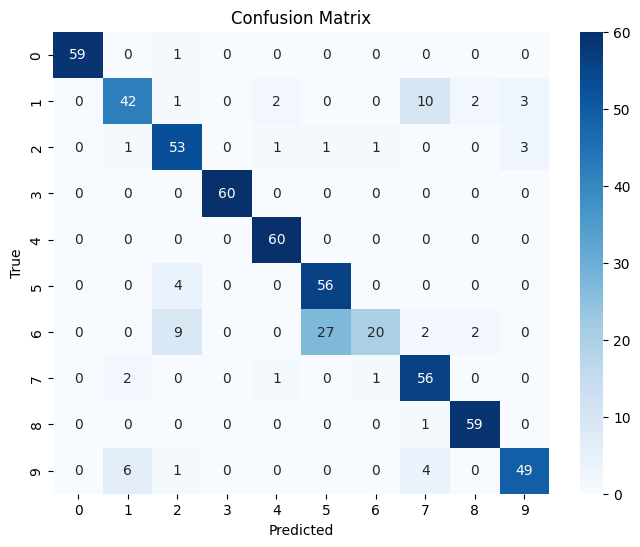

In [24]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False

# MLP Probe 
class MLPProbe(nn.Module):
    def __init__(self, backbone, feature_dim=1024, hidden_dim=512, num_classes=10, dropout=0.5):
        super().__init__()
        self.backbone = backbone
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():  # freeze backbone
            features = self.backbone(x).flatten(1)
        return self.mlp(features)

model = MLPProbe(backbone, feature_dim=1024, hidden_dim=512, num_classes=10).to(device)

# Data 
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

#Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.mlp.parameters(), lr=0.01, momentum=0.9)
epochs = 80

for epoch in range(epochs):
    model.train()
    correct = total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    print(f"Epoch {epoch+1}/{epochs} Train Acc: {100*correct/total:.2f}%")

#Evaluation 
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\n FINAL TEST ACCURACY: {100*correct/total:.2f}%")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, digits=4))

#Confusion Matrix as Image 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


****SVM****


 SVM TEST ACCURACY: 88.50%

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        60
           1     0.8824    0.7500    0.8108        60
           2     0.7727    0.8500    0.8095        60
           3     1.0000    1.0000    1.0000        60
           4     0.9062    0.9667    0.9355        60
           5     0.8364    0.7667    0.8000        60
           6     0.7931    0.7667    0.7797        60
           7     0.8667    0.8667    0.8667        60
           8     0.9365    0.9833    0.9593        60
           9     0.8571    0.9000    0.8780        60

    accuracy                         0.8850       600
   macro avg     0.8851    0.8850    0.8840       600
weighted avg     0.8851    0.8850    0.8840       600



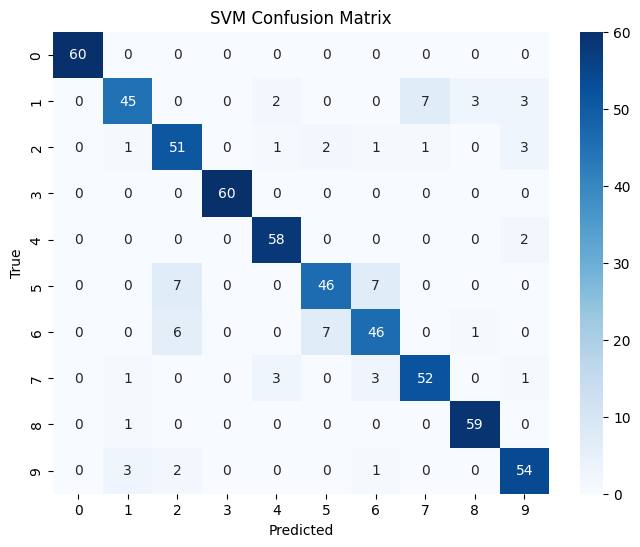

In [25]:
import torch
from torch import nn
from torchvision import datasets, transforms
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# ======= Feature Extraction 
# Freeze backbone
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

def extract_features(dataloader):
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = backbone(images).flatten(1)  # flatten
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Data
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Extract features
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# ======= SVM Training 
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

# ======= Evaluation 
y_pred = svm_clf.predict(X_test)

print(f"\n SVM TEST ACCURACY: {100*np.mean(y_pred==y_test):.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix as image
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")
plt.show()


****Decision Tree****


 Decision Tree TEST ACCURACY: 70.67%

Classification Report:
               precision    recall  f1-score   support

           0     0.9219    0.9833    0.9516        60
           1     0.5161    0.5333    0.5246        60
           2     0.6000    0.6500    0.6240        60
           3     0.9643    0.9000    0.9310        60
           4     0.8000    0.8000    0.8000        60
           5     0.6471    0.5500    0.5946        60
           6     0.4839    0.5000    0.4918        60
           7     0.6607    0.6167    0.6379        60
           8     0.8485    0.9333    0.8889        60
           9     0.6207    0.6000    0.6102        60

    accuracy                         0.7067       600
   macro avg     0.7063    0.7067    0.7055       600
weighted avg     0.7063    0.7067    0.7055       600



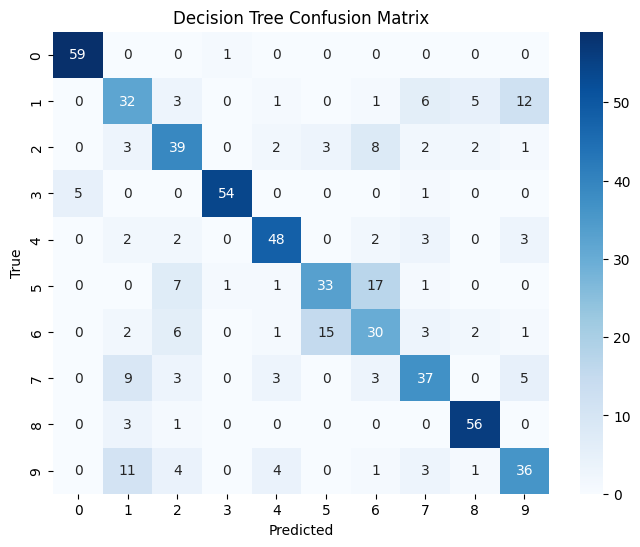

In [26]:
import torch
from torchvision import datasets, transforms
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Freeze Backbone 
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()

# Feature Extraction 
def extract_features(dataloader):
    features_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            features = backbone(images).flatten(1)  # flatten to (batch, features)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    X = np.concatenate(features_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    return X, y

# Data Loaders 
transform = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
train_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/train", transform=transform),
    batch_size=32, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    datasets.ImageFolder("/kaggle/working/prdb_ssl/split_data/test", transform=transform),
    batch_size=32, shuffle=False
)

# Extract features
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# ======= Decision Tree ======= #
dt_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_clf.fit(X_train, y_train)

# ======= Evaluation ======= #
y_pred = dt_clf.predict(X_test)

print(f"\n Decision Tree TEST ACCURACY: {100*np.mean(y_pred==y_test):.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree Confusion Matrix")
plt.show()
